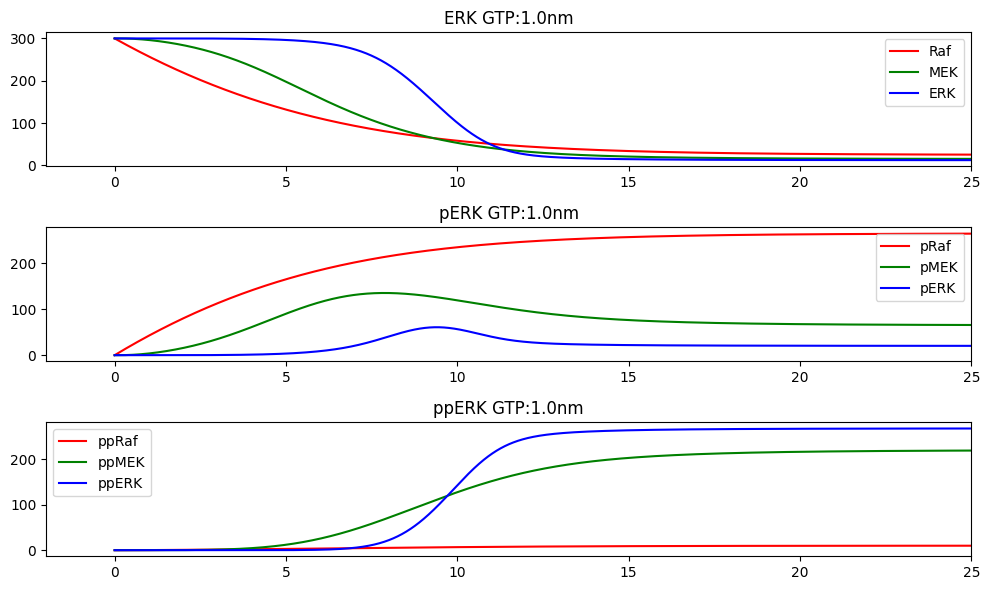

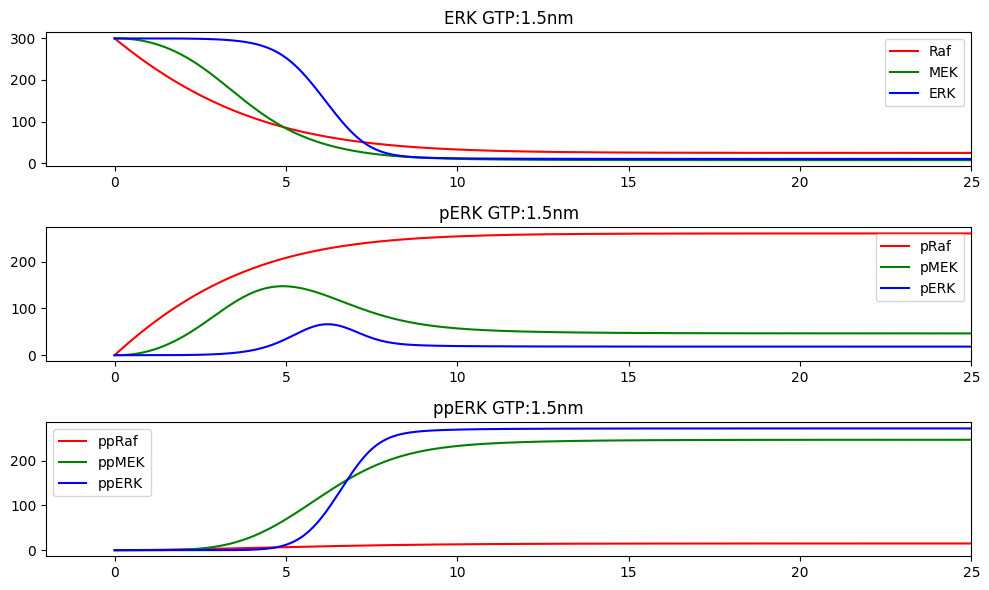

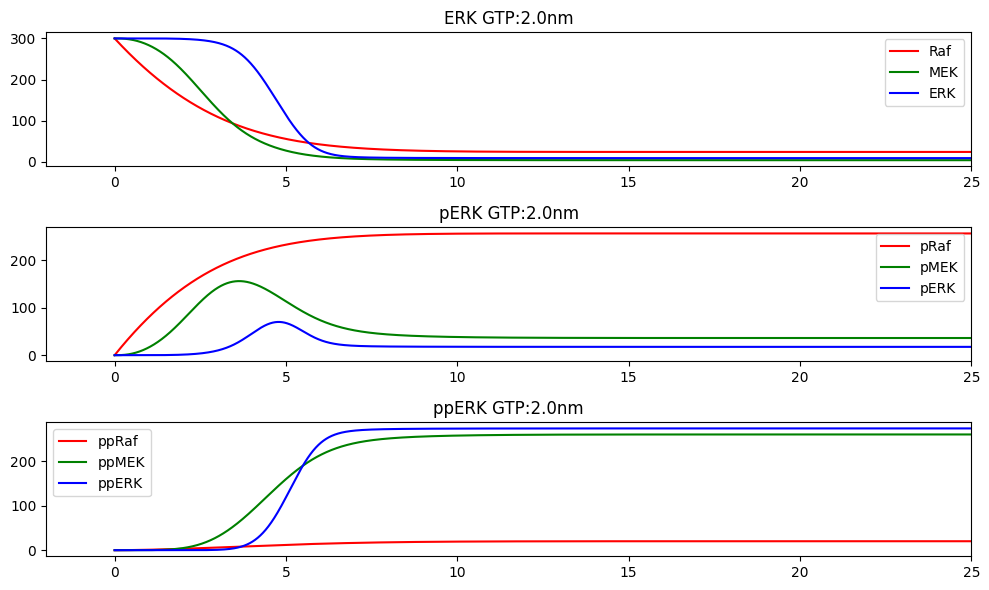

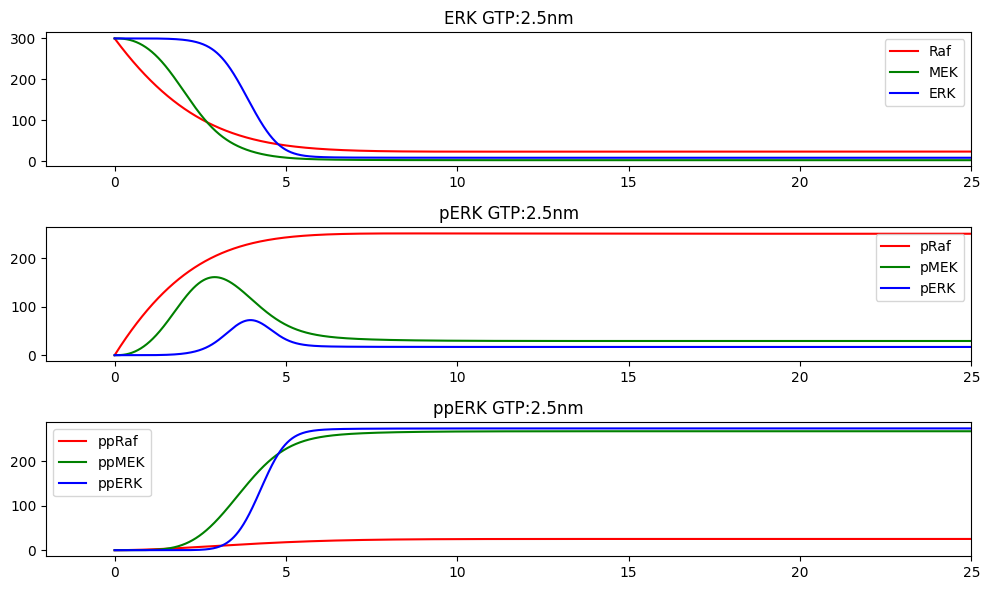

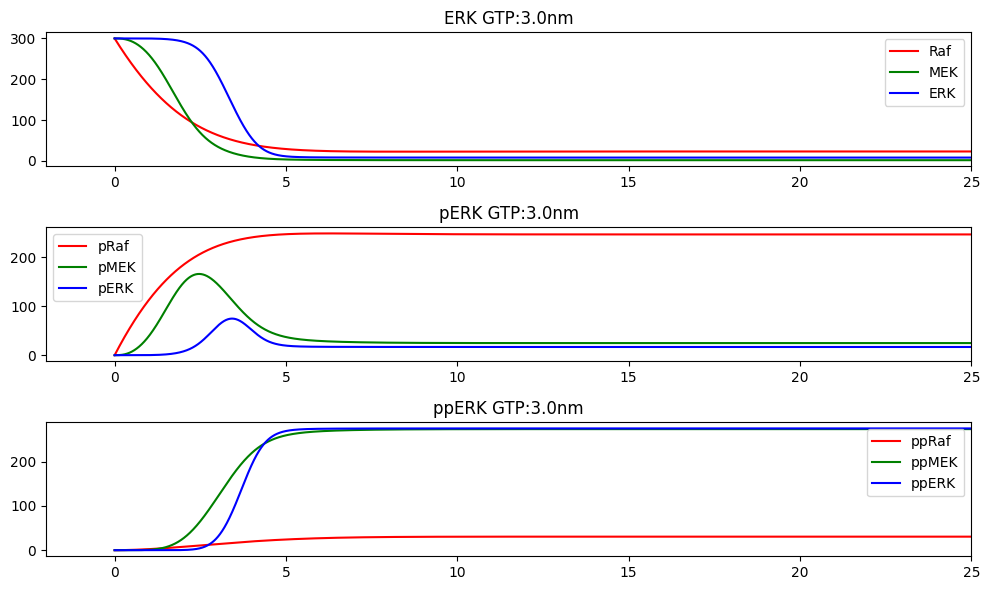

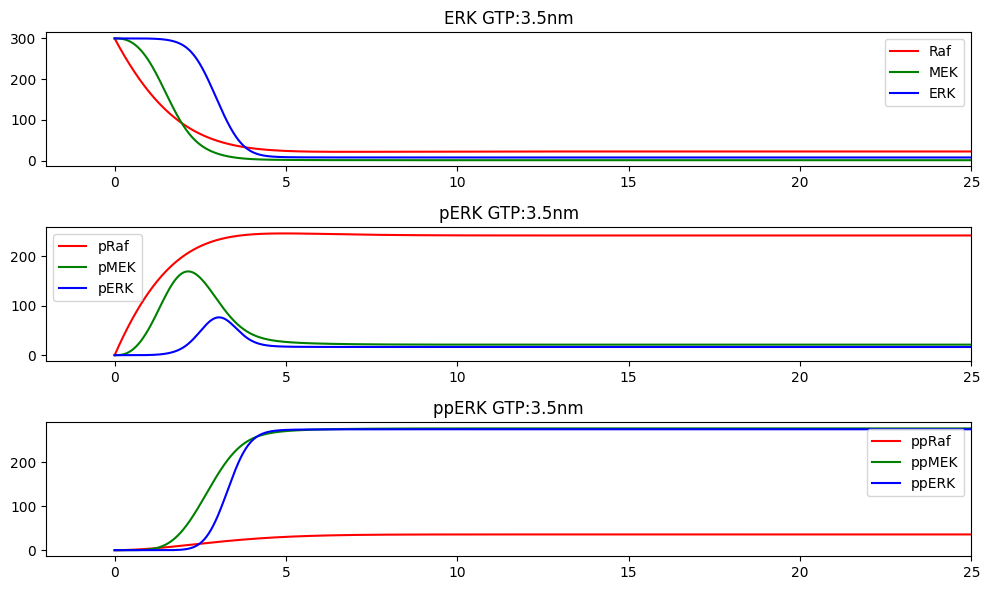

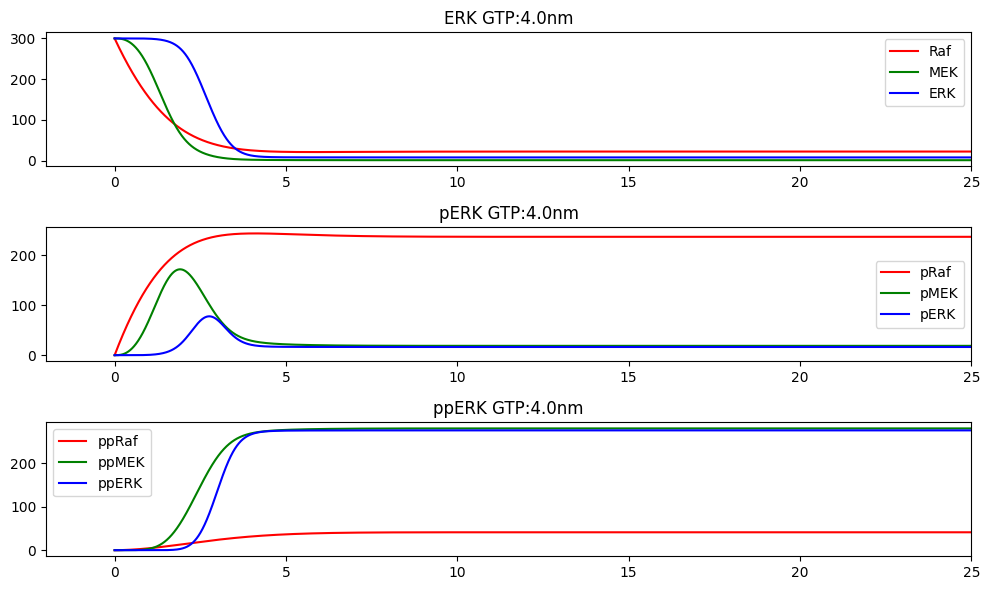

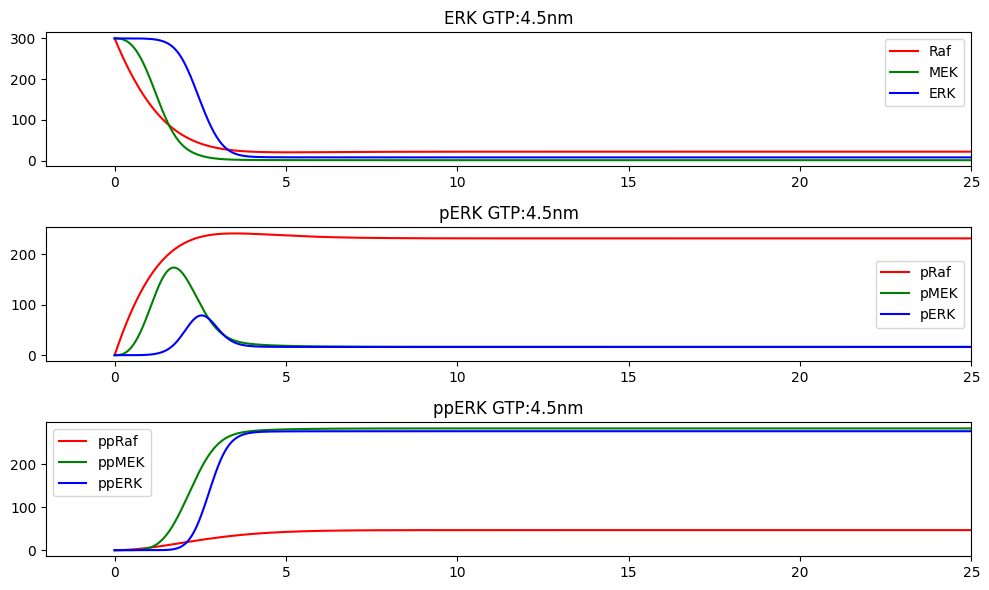

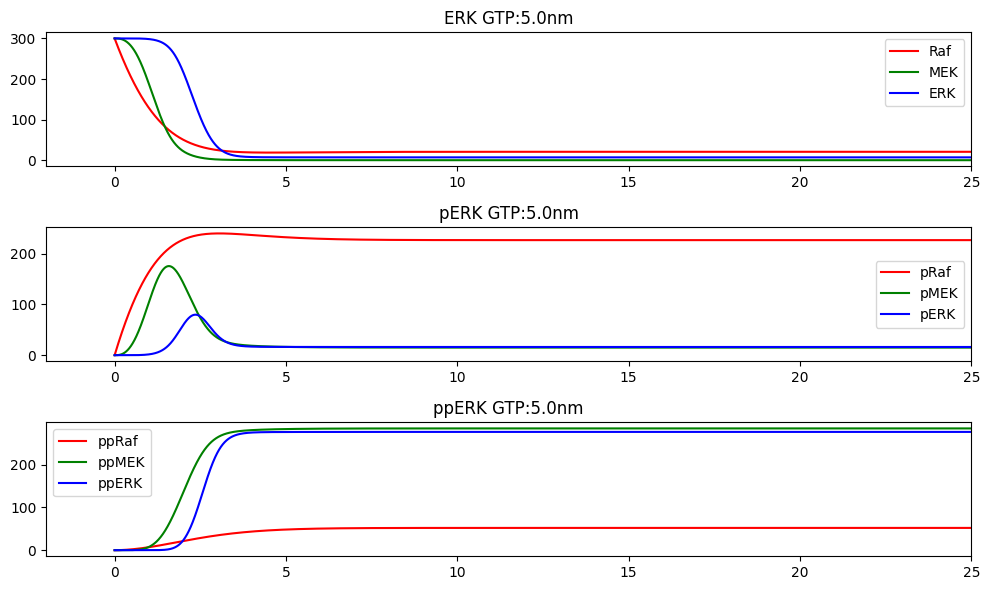

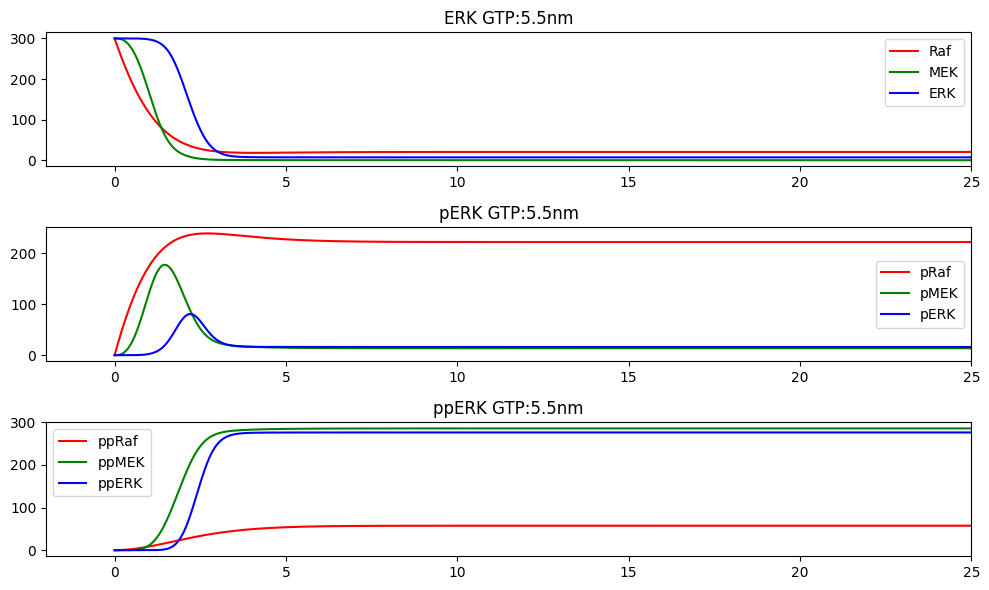

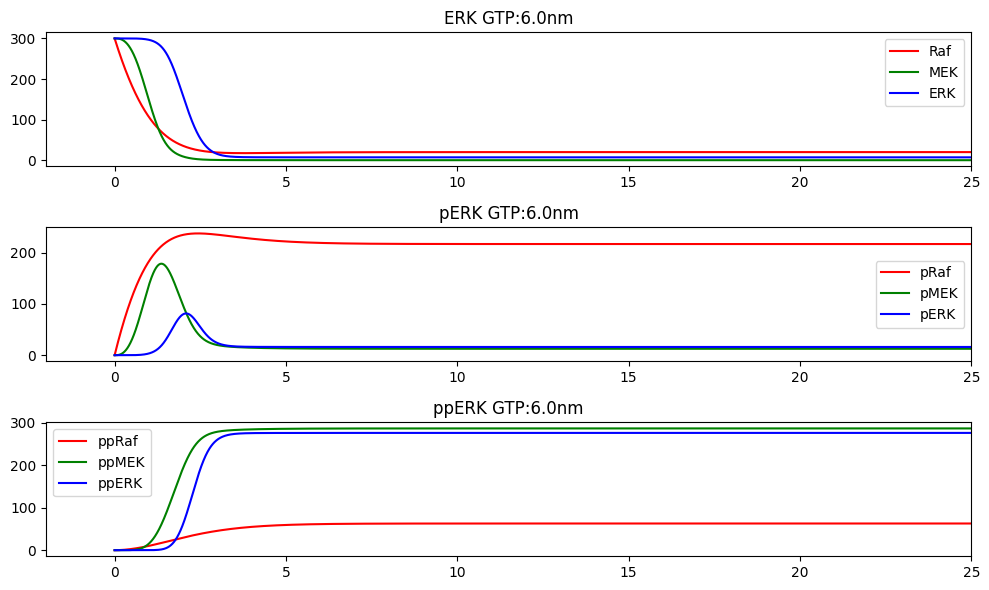

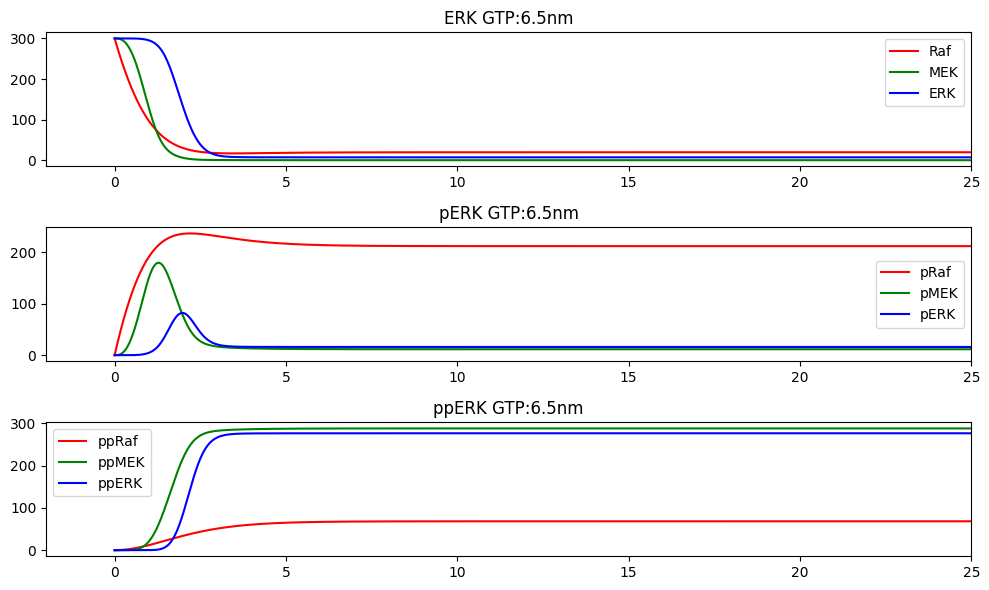

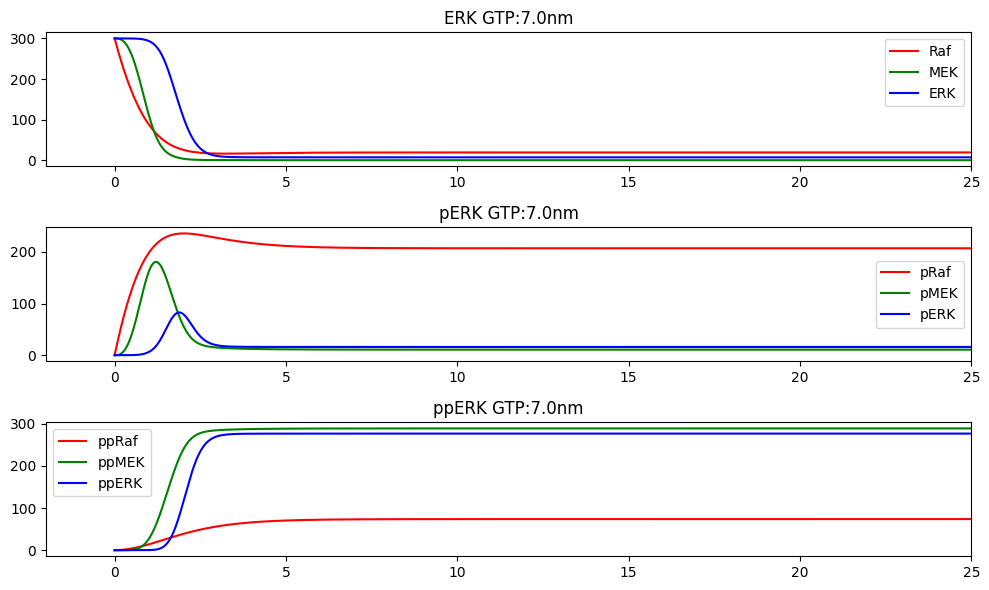

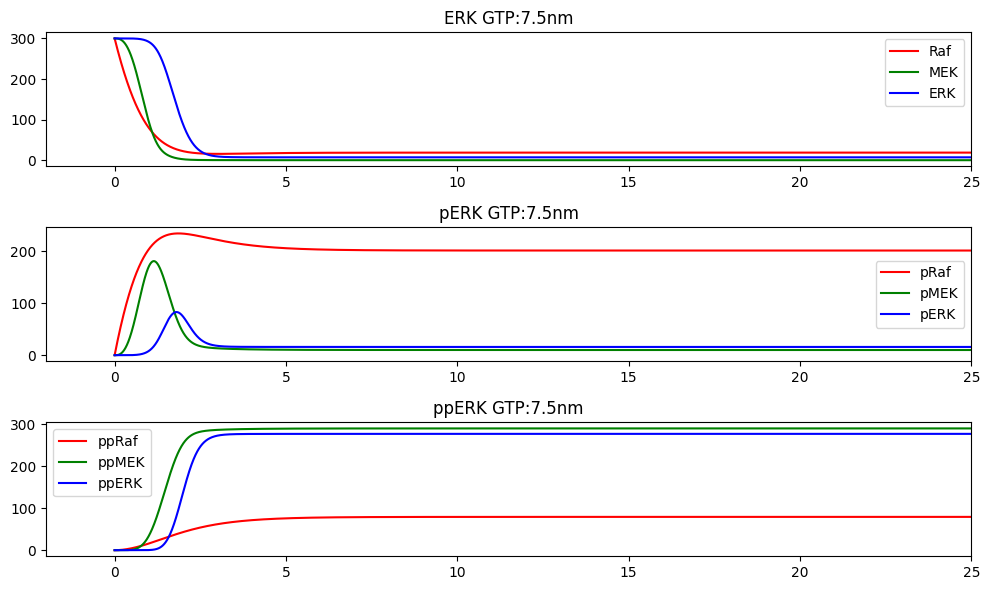

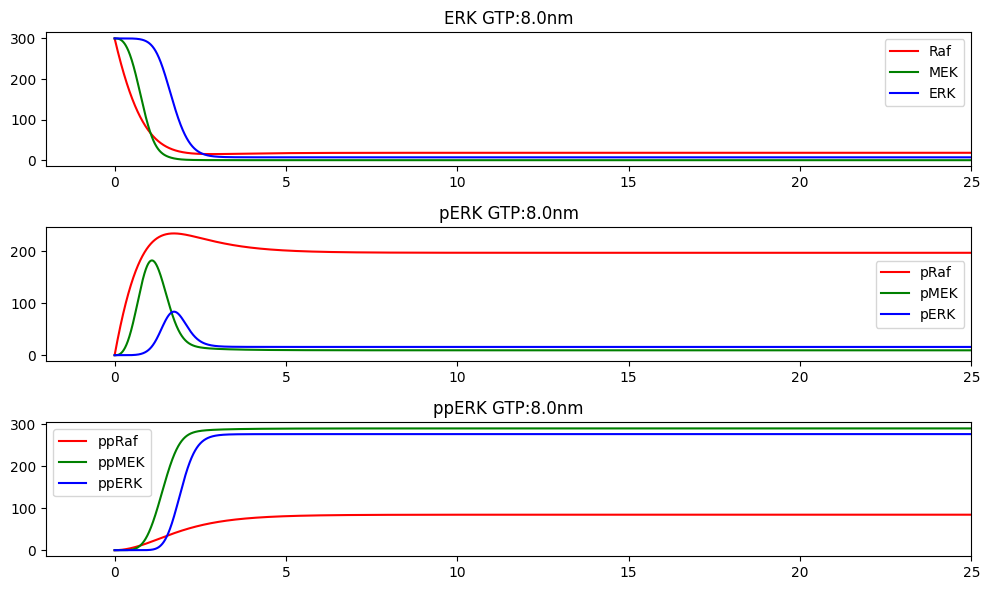

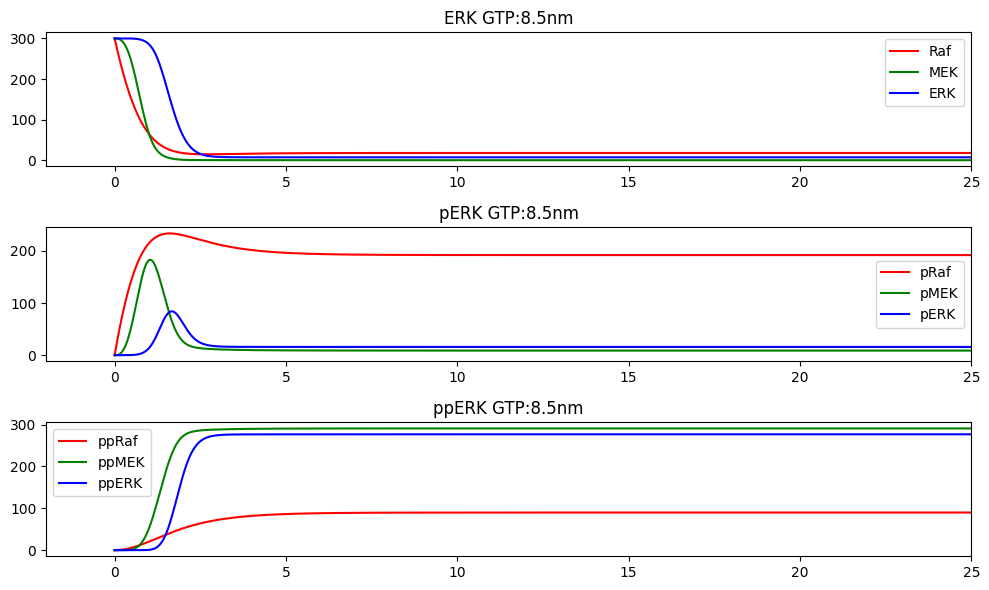

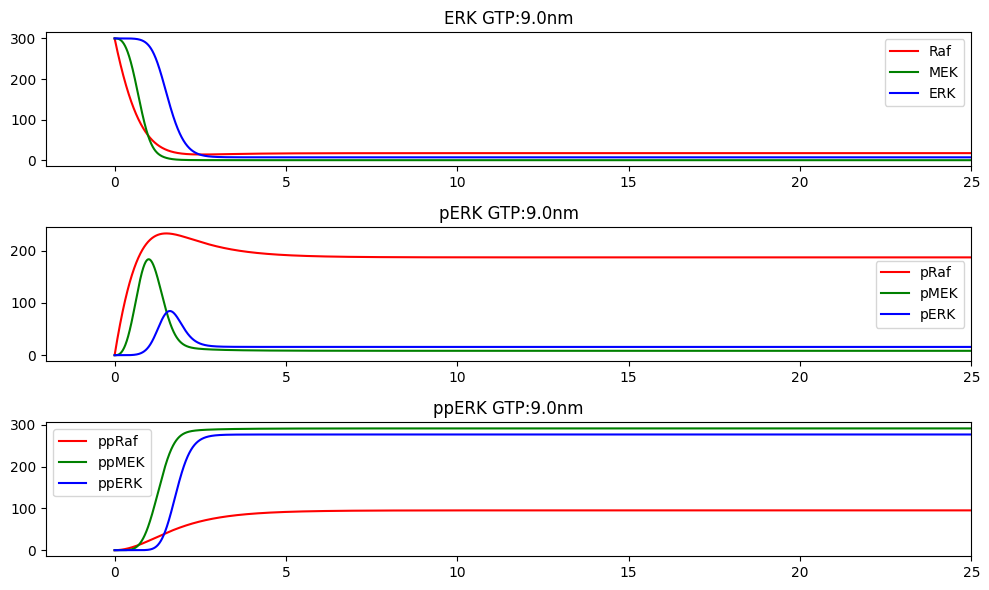

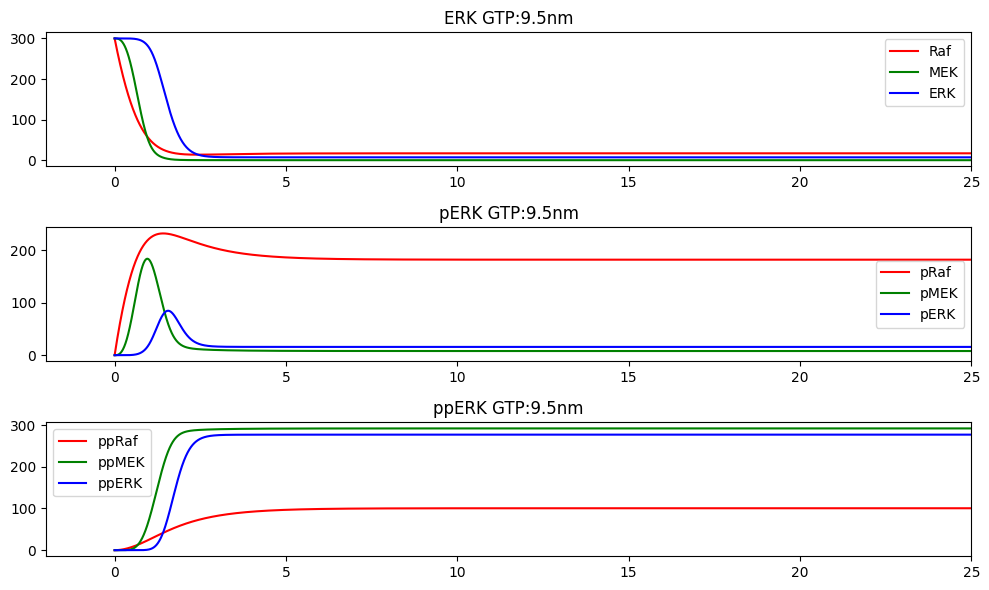

In [23]:
#!/usr/bin/env python
# coding: utf-8

# **Study of MAPK dynamics following Fig. 1 from B.N. Kholodenko, J.F. Hancock, W. Kolch, Signalling ballet in space and time, Nat Rev Mol Cell Biol 11, pp.414-426 (2010).**

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
#get_ipython().run_line_magic('matplotlib', 'notebook')
from scipy.integrate import odeint

#Parameter values
nequ=9
k1=1.0
km1=100.0
km2=200.0
k2=0.25
k3=2.5
km3=50.0
km4=100.0
k4=3.75
k5=2.5
km5=250.0
km6=250.0
k6=0.5
k7=3.0
km7=250.0
km8=80.0
k8=3.75
k9=0.125
km9=250.0
km10=250.0
k10=0.125
k11=3.75
km11=120.0
km12=20.0
k12=5.0
km13=300.0 

# SUSTAINED SIGNALLING 
F   = 1.0 # no feedback
kf  = 1.0 # irrelevant if F=1.0
GTP = 1.0
k1  = 1.0 # nm / s
k11 = 3.75 # nM


#initial conditions
y0 =  [0] * nequ
y0[0] = y0[3] = y0[6] = 300.0
y0[8] = 0.0
y0[6] = 300.0 - y0[8]


#Derivatives
def dy_dt(y,t):
    RAF, pRAF, ppRAF, MEK, pMEK, ppMEK, ERK, pERK, ppERK = y

    v1 = ( (k1*gtp*RAF)   / km1 ) / ( 1+(RAF/km1)+(pRAF/km2) )
    v2 = ( (k2*gtp*pRAF)  / km2 ) / ( 1+(RAF/km1)+(pRAF/km2) )
    v3 = ( (k3*ppRAF) / km3 )     / ( 1+(ppRAF/km3)+(pRAF/km4) )
    v4 = ( (k4*ppRAF) / km4 )     / ( 1+(ppRAF/km3)+(pRAF/km4) )

    v5 = ( (k5*ppRAF*MEK)  / km5 )  / ( 1+(MEK/km5)+(pMEK/km6) )
    v6 = ( (k6*ppRAF*pMEK) / km6 )  / ( 1+(MEK/km5)+(pMEK/km6) )
    v7 = ( (k7*ppMEK) / km7 )       / ( 1+(ppMEK/km7)+(pMEK/km8) )
    v8 = ( (k8*pMEK)  / km8 )       / ( 1+(ppMEK/km7)+(pMEK/km8) )

    v9  = ( (k9*ppMEK*ERK)   / km9 )   / ( 1+(ERK/km9)+(pERK/km10) )
    v10 = ( (k10*ppMEK*pERK) / km10 )  / ( 1+(ERK/km9)+(pERK/km10) )
    v11 = ( (k11*ppERK) / km11 )       / ( 1+(ppERK/km11)+(pERK/km12) )
    v12 = ( (k12*pERK)  / km12 )       / ( 1+(ppERK/km11)+(pERK/km12) )
    
    dy = []
    dy.append( v4 - v1 )           # RAF
    dy.append( v1 - v2 + v3 - v4 ) # pRAF
    dy.append( v2 - v3 )           # ppRAF

    dy.append( v8 - v5 )           # MEK
    dy.append( v5 - v6 + v7 - v8 ) # pMEK
    dy.append( v6 - v7 )           # ppMEK

    dy.append( v12 - v9 )             # ERK
    dy.append( v9 - v10 + v11 - v12 ) # pERK
    dy.append( v10 - v11 )            # ppERK
    return dy    

#Integration of ODEs
GTP = np.arange(1,10,0.5)
for gtp in GTP:
    #initial conditions
    y0 =  [0] * nequ
    y0[0] = y0[3] = y0[6] = 300.0
    y0[8] = 0.0
    y0[6] = 300.0 - y0[8]
    
    t_min = 50
    t = np.linspace(0, t_min * 60 + 1, 10000)
    sol = odeint(func=dy_dt, y0=y0, t=t)
    sol = pd.DataFrame(sol, columns=["Raf", "pRaf","ppRaf","MEK","pMEK","ppMEK","ERK","pERK","ppERK"])

    sol.index = t
    sol.index = sol.index/60

    fig, ax = plt.subplots(3,1, figsize=(10,6))
    colors=['red', 'red', 'red', 'green', 'green', 'green', 'blue', 'blue', 'blue']
    for i, col in enumerate(sol.columns):
        r = i // 3
        c = i % 3
        ax[c].plot(sol.index, sol[col], color=colors[i], label=col)
        ax[c].set_title(f'{col} GTP:{gtp}nm')
        ax[c].legend()
        ax[c].set_xlim(-2, 25)
    plt.tight_layout()
    plt.show()

